# Module 6 - Multivariate Analysis

Multivariate analysis studies relationships among three or more variables at the same time. It helps identify patterns and interactions that may not be visible when analyzing variables individually.

This notebook uses the Hotel Booking Demand dataset to analyze relationships among multiple features using correlation, visualizations, and feature analysis.

## 1. Setup and Data Load

The required libraries are imported and the Hotel Booking Demand dataset is loaded for multivariate analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/hotel_bookings.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Interpretation

The dataset is loaded into a Pandas DataFrame, and the first few records are displayed to verify the data.

### Findings

The dataset contains multiple booking-related variables that can be analyzed together to identify relationships and patterns.

### AI/ML Relevance

Understanding the dataset before multivariate analysis helps identify suitable features and relationships for further Machine Learning analysis.

## 2. Correlation Matrix

A correlation matrix shows the relationship between multiple numerical variables at the same time.

The correlation value ranges from -1 to +1. A value close to +1 indicates a strong positive relationship, a value close to -1 indicates a strong negative relationship, and a value close to 0 indicates a weak linear relationship.

### Example

In the Hotel Booking Demand dataset, numerical variables such as lead time, stay duration, number of guests, and average daily rate can be compared using a correlation matrix.

### Real-World Example

A hotel can use correlation analysis to understand whether booking time, length of stay, and room rates are related.

### AI/ML Usage

Correlation analysis helps identify related features and possible multicollinearity before Machine Learning.

In [2]:
numeric_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes",
    "adr",
    "total_of_special_requests"
]

corr_matrix = df[numeric_cols].corr()

print(corr_matrix.round(2))

                           lead_time  stays_in_weekend_nights  \
lead_time                       1.00                     0.09   
stays_in_weekend_nights         0.09                     1.00   
stays_in_week_nights            0.17                     0.50   
adults                          0.12                     0.09   
children                       -0.04                     0.05   
babies                         -0.02                     0.02   
previous_cancellations          0.09                    -0.01   
booking_changes                 0.00                     0.06   
adr                            -0.06                     0.05   
total_of_special_requests      -0.10                     0.07   

                           stays_in_week_nights  adults  children  babies  \
lead_time                                  0.17    0.12     -0.04   -0.02   
stays_in_weekend_nights                    0.50    0.09      0.05    0.02   
stays_in_week_nights                       1.00    0.

### Interpretation

The correlation matrix shows the strength and direction of the relationships between the selected numerical variables.

### Findings

The matrix can be used to identify strongly related variables, weak relationships, and negative relationships between numerical features.

### AI/ML Relevance

Highly correlated features may contain similar information and can lead to multicollinearity, so they should be reviewed before Machine Learning.

## 3. Heatmap

A heatmap is a visual representation of numerical values using different shades to make patterns easier to identify.

A correlation heatmap displays the correlation values between multiple numerical variables and makes strong and weak relationships easier to see.

### Example

In the Hotel Booking Demand dataset, a heatmap can be used to visualize relationships between booking, stay, guest, and rate-related features.

### Real-World Example

A hotel can use a correlation heatmap to quickly identify which booking factors are strongly related to each other.

### AI/ML Usage

A heatmap helps identify important feature relationships and possible multicollinearity before Machine Learning.

### Implementation

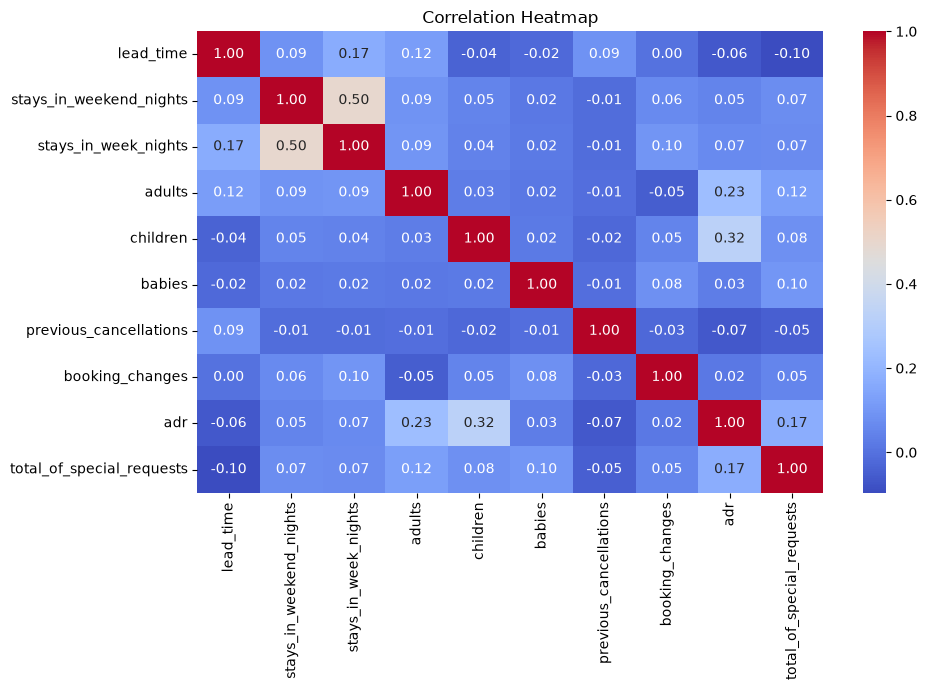

In [3]:
plt.figure(figsize=(10, 7))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Interpretation

The heatmap represents the correlation values between the selected numerical features.

Values closer to 1 indicate a strong positive relationship, while values closer to -1 indicate a strong negative relationship. Values near 0 indicate a weak relationship.

### Findings

The heatmap makes it easier to identify the strongest and weakest relationships among the selected features and helps highlight feature pairs that may need further investigation.

### AI/ML Relevance

A correlation heatmap helps identify redundant features and possible multicollinearity, which can be important during feature selection and model preparation.

## 4. Pair Plot

A pair plot shows the relationships and distributions of multiple numerical variables in a single visualization.

It helps compare several feature pairs and observe possible patterns, trends, and relationships.

### Example

In the Hotel Booking Demand dataset, a pair plot can be used to compare lead time, stay duration, number of guests, and average daily rate.

### Real-World Example

A hotel can use a pair plot to explore how booking time, stay duration, guest count, and room rates are related.

### AI/ML Usage

Pair plots help identify relationships, clusters, trends, and potential outliers among multiple numerical features before Machine Learning.

### Implementation

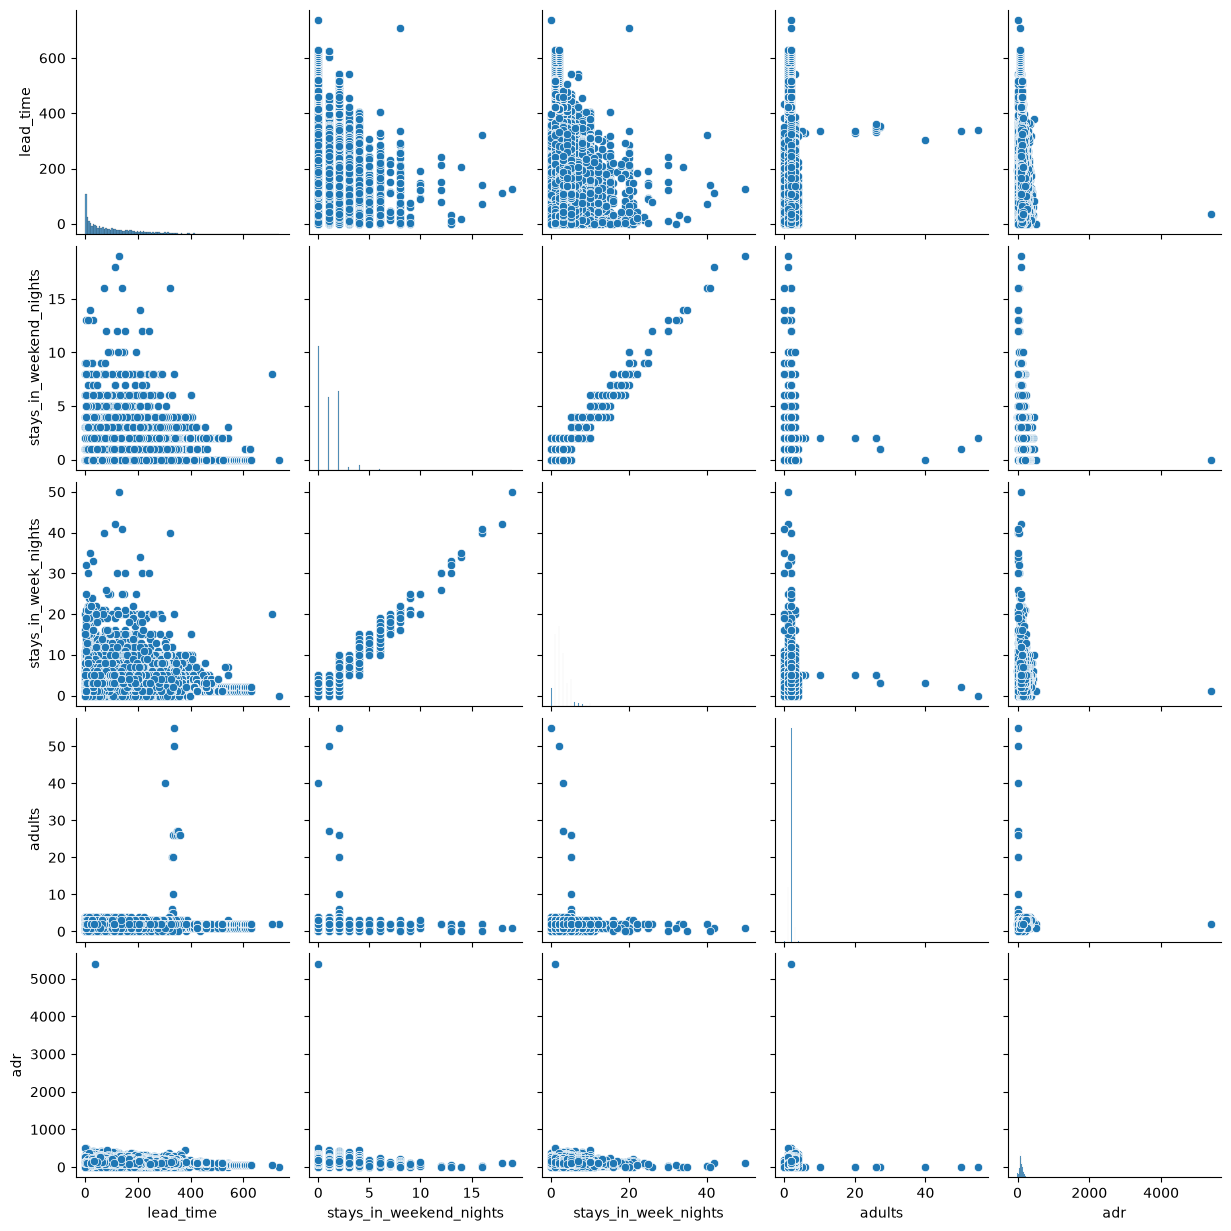

In [5]:
pair_cols = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "adr"
]

sns.pairplot(df[pair_cols].dropna())

plt.show()

### Interpretation

The pair plot shows the distribution of each selected numerical feature and the relationship between every pair of features.

### Findings

The plots help identify visible trends, clusters, strong relationships, weak relationships, and unusual observations between the selected features.

### AI/ML Relevance

Pair plots provide a broad view of numerical feature relationships and can support feature selection and further exploratory analysis before model development.

## 5. Multiple Feature Relationships

Multiple feature relationship analysis examines several variables together to understand how they interact and influence patterns in the dataset.

In the Hotel Booking Demand dataset, lead time, length of stay, number of adults, and average daily rate can be analyzed together.

### Example

A hotel may study whether booking lead time and stay duration are related to the average daily rate for different booking records.

### Real-World Example

Hotel management can use multiple booking features together to understand customer booking behavior and pricing patterns.

### AI/ML Usage

Analyzing multiple features together helps identify useful relationships and interactions that may be important for Machine Learning.

### Implementation

In [6]:
selected_features = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "adr"
]

print(df[selected_features].corr().round(2))

                         lead_time  stays_in_weekend_nights  \
lead_time                     1.00                     0.09   
stays_in_weekend_nights       0.09                     1.00   
stays_in_week_nights          0.17                     0.50   
adults                        0.12                     0.09   
adr                          -0.06                     0.05   

                         stays_in_week_nights  adults   adr  
lead_time                                0.17    0.12 -0.06  
stays_in_weekend_nights                  0.50    0.09  0.05  
stays_in_week_nights                     1.00    0.09  0.07  
adults                                   0.09    1.00  0.23  
adr                                      0.07    0.23  1.00  


### Interpretation

The output shows the relationships between multiple selected numerical features.

### Findings

The correlation values help identify which features have stronger, weaker, or negative relationships with each other.

### AI/ML Relevance

Understanding multiple feature relationships helps identify useful inputs and possible redundant features before Machine Learning.

## 6. Feature Interactions

Feature interactions occur when the relationship or effect of one feature depends on another feature.

Analyzing feature interactions helps us understand how multiple variables work together rather than examining them separately.

### Example

In the Hotel Booking Demand dataset, lead time and hotel type can be studied together to understand differences in booking behavior.

### Real-World Example

A hotel may observe that booking patterns differ between City Hotel and Resort Hotel depending on how early customers make their reservations.

### AI/ML Usage

Feature interactions can provide additional information to Machine Learning models and help identify patterns that may not be visible from individual features.

### Implementation

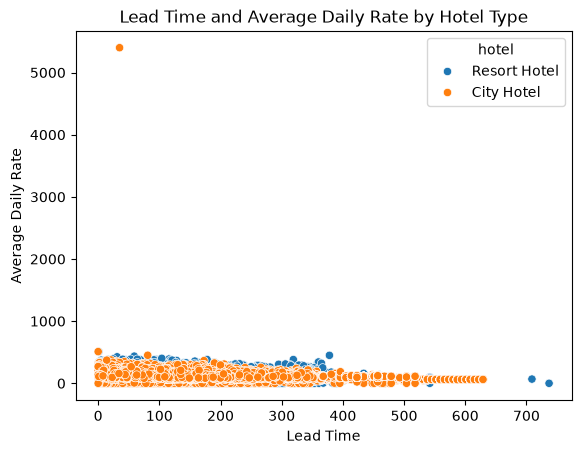

In [7]:
sns.scatterplot(
    data=df,
    x="lead_time",
    y="adr",
    hue="hotel"
)

plt.title("Lead Time and Average Daily Rate by Hotel Type")
plt.xlabel("Lead Time")
plt.ylabel("Average Daily Rate")
plt.show()

### Interpretation

The plot shows the relationship between lead time and average daily rate while also separating the observations by hotel type.

### Findings

Comparing the groups can help identify whether the relationship between booking lead time and room rate changes across hotel types.

### AI/ML Relevance

Feature interactions can help improve the understanding of complex patterns and may provide useful information for Machine Learning feature engineering.

## 7. Numerical Feature Relationships

Numerical feature relationship analysis compares multiple numerical variables to understand how they are related to each other.

In the Hotel Booking Demand dataset, variables such as lead time, stay duration, number of adults, and average daily rate can be compared to identify useful patterns.

### Example

Comparing lead time with average daily rate can help determine whether booking time is related to room pricing.

### Real-World Example

A hotel can analyze numerical booking features to understand customer booking behavior and pricing patterns.

### AI/ML Usage

Understanding relationships between numerical features helps identify important variables, redundant information, and possible multicollinearity before Machine Learning.

### Implementation

In [8]:
features = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "adr"
]

relationship_matrix = df[features].corr()

print(relationship_matrix.round(2))

                         lead_time  stays_in_weekend_nights  \
lead_time                     1.00                     0.09   
stays_in_weekend_nights       0.09                     1.00   
stays_in_week_nights          0.17                     0.50   
adults                        0.12                     0.09   
adr                          -0.06                     0.05   

                         stays_in_week_nights  adults   adr  
lead_time                                0.17    0.12 -0.06  
stays_in_weekend_nights                  0.50    0.09  0.05  
stays_in_week_nights                     1.00    0.09  0.07  
adults                                   0.09    1.00  0.23  
adr                                      0.07    0.23  1.00  


### Interpretation

The output shows the correlation values between the selected numerical features.

Higher positive values indicate that two features tend to increase together, while negative values indicate an inverse relationship.

### Findings

The correlation values help identify strong, weak, and negative relationships between the numerical features.

These relationships can be investigated further to understand possible dependencies among the variables.

### AI/ML Relevance

Numerical feature relationships help in feature selection and identifying potential multicollinearity before developing Machine Learning models.